<a href="https://colab.research.google.com/github/NatakiSystems/jupyterlab/blob/main/N_Boykin_HWRK_answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization Part 2 — Homework Assignment
## **Case Study: MegaMart Retail Chain**

You have been brought on as a junior data analyst at MegaMart, a nationwide retail chain. Your manager has handed you a raw sales dataset and asked you to clean it up and create some simple charts to help the team understand how the business is performing.

This homework mirrors exactly what you practiced in class — you will check data types, fix date columns, extract date parts, check for missing values, and then create visualizations using that clean data.

---

## Dataset Overview
You will be working with `superstore_sales_2019_2022.csv` — a simulated dataset of a nationwide retail chain with 9,994 transactions from 2019–2022. The dataset includes sales data across multiple product categories, regions, customer segments, and shipping modes.

### Dataset Column Reference
| Column | Description |
|---|---|
| `Order_ID` | Unique order identifier |
| `Order_Date` | Date the order was placed (YYYY-MM-DD) |
| `Ship_Date` | Date the order was shipped |
| `Ship_Mode` | Shipping method (Standard Class, Second Class, etc.) |
| `Customer_ID` | Unique customer identifier |
| `Customer_Name` | Customer name |
| `Segment` | Customer segment (Consumer, Corporate, Home Office) |
| `City`, `State`, `Region`, `Country` | Geographic information |
| `Category` | Product category (Furniture, Office Supplies, Technology) |
| `Sub_Category` | Product sub-category |
| `Product_Name` | Name of the product |
| `Sales` | Total sales amount ($) |
| `Quantity` | Number of units sold |
| `Discount` | Discount percentage applied |
| `Profit` | Profit amount ($) |
| `Returned` | Whether the item was returned (Yes / No) |

---

## Interested in reading more about retail data analytics?
- Harvard Business Review. (2023). [How to Make Your Company's Data Accessible.](https://hbr.org/2023/01/how-to-make-your-companys-data-accessible)
- McKinsey & Company. (2021). [Retail's need for speed: How analytics and AI can help.](https://www.mckinsey.com/industries/retail/our-insights/retails-need-for-speed-how-analytics-and-ai-can-help)
- U.S. Census Bureau. (2023). [Monthly Retail Trade Report.](https://www.census.gov/retail/index.html)

> **Please note:** All links were verified as active and accessible as of December 2025. Some resources may require free registration or have monthly article limits for free readers.

---
## ✅ Step 0: Set Up Your Notebook and Environment

Before continuing, be sure to **MAKE A COPY OF THIS NOTEBOOK** as this will contain your answers. Name the copy the following:
- firstInitial_lastName_HWRK_answers.ipynb
- Example: j_ortiz_HWRK_answers.ipynb

Once you have done so, return to this step in your copy

Before running any code, make sure you have the required libraries installed.

**If you are using Google Colab, you can skip the step with setting up the virtual environment**

Open your terminal, navigate to the folder where your notebook is saved, and run:

```bash
python -m venv .venv

```

Then activate the virtual environment.

After all that, you can run the following cell:

In [1]:
%pip install pandas numpy matplotlib seaborn

> 💡 **Tip:** You only need to do this once. If you already installed these during class, you can skip this step.

---
## ✅ Step 1: Import the Required Libraries

Run the code cell below. It imports all the tools you need for this assignment.

> 💡 **What is this doing?** Just like in class, we import `pandas` to work with data, and `matplotlib` / `seaborn` to make charts. You do not need to change anything here — just run it.

In [2]:
# ============================================================================
# Step 2: Import Libraries — run this cell as-is, no changes needed
# ============================================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean chart style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("colorblind")

# Make charts a bit bigger and easier to read
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Show all columns when printing a DataFrame
pd.set_option('display.max_columns', None)

print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


---
## ✅ Step 2: Load the Data

Run the cell below to load the CSV file into a pandas DataFrame.

⚠️ **Important:** Make sure `superstore_sales_2019_2022.csv` is saved in the **same folder** as your notebook. If it is not, you will get this error:
```
FileNotFoundError: [Errno 2] No such file or directory: 'superstore_sales_2019_2022.csv'
```
If you see that error, move the CSV file into the same folder as your `.ipynb` file and try again.

In [3]:
# ============================================================================
# Step 3: Load the CSV file — run this cell as-is
# ============================================================================

df = pd.read_csv('superstore_sales_2019_2022.csv')

print("Dataset loaded successfully! ✅")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully! ✅
Number of rows: 9999
Number of columns: 19


---
# 🧹 Part 1: Data Cleaning

Before we can make any charts, we need to clean the data — just like we covered in class.

Remember: **"Garbage In, Garbage Out."** If our data has issues, our charts will too.

We will work through these cleaning steps one at a time:
1. Check what data types pandas assigned to each column
2. Fix the date columns
3. Extract useful date parts (year, month) into new columns
4. Check for and handle missing values
5. Check for duplicate rows
6. Standardize the `Returned` column

---
### 🔍 Part 1 — Task 1: Check Your Data Types

The first thing we always do is check what types pandas assigned to each column. Remember from class:
- `object` → text (or mixed types)
- `int64` → whole numbers
- `float64` → decimal numbers
- `datetime64` → dates and times ✅ *(this is what we want for date columns)*

**Your task:** Run the cell below.

In [4]:
# ============================================================================
# Part 1 - Task 1: Check data types — run this cell as-is
# ============================================================================

print("=== Column Data Types ===")
print(df.dtypes)

print("\n=== First 5 Rows ===")
display(df.head())

=== Column Data Types ===
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
City              object
State             object
Region            object
Country           object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
Returned          object
dtype: object

=== First 5 Rows ===


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,City,State,Region,Country,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Returned
0,CA-2020-103657,2019-07-19,2019-07-24,Same Day,CG-10118,Customer_119,Consumer,City_17,Michigan,Central,USA,Furniture,Furnishings,Furnishings 833,549.53,2,0.0,155.09,No
1,CA-2022-102539,2021-09-25,2021-09-28,Second Class,CG-10189,Customer_190,Corporate,City_23,North Carolina,East,USA,Office Supplies,Paper,Paper 151,124.80,1,0.0,43.95,No
2,CA-2022-109775,2021-04-06,2021-04-13,Standard Class,CG-10217,Customer_218,Consumer,City_40,Minnesota,Central,USA,Office Supplies,Labels,Labels 821,770.36,3,0.2,129.18,No
3,CA-2019-103320,2020-11-10,2020-11-16,Standard Class,CG-10552,Customer_553,Corporate,City_4,Mississippi,South,USA,Office Supplies,Art,Art 857,213.96,1,0.0,57.31,No
4,CA-2020-102301,2019-06-06,2019-06-13,Second Class,CG-10092,Customer_93,Corporate,City_16,New York,East,USA,Office Supplies,Storage,Storage 458,11.17,1,0.5,-0.37,No


---
### 🔧 Part 1 — Task 2: Fix the Date Columns

As we saw in class, pandas loads date columns as `object` (text) by default — it does not assume intent. We need to explicitly tell pandas that `Order_Date` and `Ship_Date` are dates using `pd.to_datetime()`.

**Your task:** Fill in the two blanks in the code cell below to convert both date columns.

> 💡 **Hint:** In class we used: `df['Order_Date'] = pd.to_datetime(df['Order_Date'])`

In [5]:
# ============================================================================
# Part 1 - Task 2: Convert date columns to datetime
# Fill in the two blanks below (replace the underscores with your code)
# ============================================================================

# Convert Order_Date to datetime
df['Order_Date'] = df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Convert Ship_Date to datetime
df['Ship_Date'] = df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

# Check that it worked — both should now show datetime64
print("Updated data types:")
print(df[['Order_Date', 'Ship_Date']].dtypes)

Updated data types:
Order_Date    datetime64[ns]
Ship_Date     datetime64[ns]
dtype: object


---
### 📅 Part 1 — Task 3: Extract Date Parts into New Columns

Now that `Order_Date` is a proper datetime, we can use the `.dt` accessor to pull out the parts we need for analysis — just like we did in class!

Remember: a datetime column is like a "box" containing year, month, day, and more. `.dt` lets you take out just the pieces you want.

**Your task:** Fill in the three blanks below to create new columns for year, month number, and month name.

> 💡 **Hint:** From class —
> - `.dt.year` → extracts the year (2019, 2020, etc.)
> - `.dt.month` → extracts the month number (1–12)
> - `.dt.strftime('%B')` → extracts the full month name (January, February, etc.)

In [6]:
# ============================================================================
# Part 1 - Task 3: Extract date parts into new columns
# Fill in the three blanks below
# ============================================================================

# Extract the year from Order_Date
df['Order_Year'] = df['Order_Date'].dt.year

# Extract the month number from Order_Date
df['Order_Month'] = df['Order_Date'].dt.month

# Extract the full month name from Order_Date
df['Order_Month_Name'] = df['Order_Date'].dt.strftime('%B')

# Check your work — preview the new columns
print("New columns added:")
display(df[['Order_Date', 'Order_Year', 'Order_Month', 'Order_Month_Name']].head(10))

New columns added:


,Order_Date,Order_Year,Order_Month,Order_Month_Name
0,2019-07-19,2019,7,July
1,2021-09-25,2021,9,September
2,2021-04-06,2021,4,April
3,2020-11-10,2020,11,November
4,2019-06-06,2019,6,June
5,2019-01-14,2019,1,January
6,2020-07-24,2020,7,July
7,2019-05-06,2019,5,May
8,2021-05-07,2021,5,May
9,2020-04-25,2020,4,April


---
### 🔍 Part 1 — Task 4: Check for Missing Values

Real-world data is never perfect. Let's check if our dataset has any missing values using `.isna()`.

Remember from class:
- `.isna()` asks "Is this value missing?" and returns `True` or `False` for every cell
- `.sum()` counts up all the `True` values (because `True == 1` in Python)

**Your task:** Run the cell below to check for missing values, then answer the question underneath.

In [7]:
# ============================================================================
# Part 1 - Task 4: Check for missing values — run this cell as-is
# ============================================================================

print("=== Missing Value Count Per Column ===")
missing_counts = df.isna().sum()
print(missing_counts)

print("\n=== Columns WITH Missing Values ===")
columns_with_missing = missing_counts[missing_counts > 0]
if len(columns_with_missing) == 0:
    print("No missing values found! ✅")
else:
    print(columns_with_missing)

=== Missing Value Count Per Column ===
Order_ID             0
Order_Date           0
Ship_Date            0
Ship_Mode            0
Customer_ID          0
Customer_Name        0
Segment              0
City                 0
State                0
Region               0
Country              0
Category             0
Sub_Category         0
Product_Name         0
Sales               15
Quantity             0
Discount             0
Profit               0
Returned             0
Order_Year           0
Order_Month          0
Order_Month_Name     0
dtype: int64

=== Columns WITH Missing Values ===
Sales    15
dtype: int64


#### 🧪 Unit Test: Verify the Sales Column Has No Missing Values

Before we use the `Sales` column in any charts, let's write a unit test to confirm it has no missing values — just like we practiced in class. A unit test is a small check that confirms our data meets a specific expectation.

**Your task:** Fill in the blank below. If the test passes, it will print a success message. If it fails, you will know the `Sales` column needs to be cleaned before moving on.

> 💡 **Hint:** From class — `df['Sales'].isna().sum()` gives you the number of missing values in Sales. If that number equals 0, there are no missing values.

In [10]:
# ============================================================================
# Part 1 - Task 4 (continued): Unit test for missing Sales values
# Fill in the blank below
# ============================================================================

# Count how many missing values are in the Sales column
missing_sales = df['Sales'].isna().sum()

# Unit test — this checks your answer automatically
assert missing_sales == 0, f"❌ Test FAILED: Sales column has {missing_sales} missing value(s). Use df.dropna(subset=['Sales']) to fix this before moving on."
print("✅ Unit test passed! The Sales column has no missing values.")

✅ Unit test passed! The Sales column has no missing values.


#### 🛠️ If Your Unit Test Failed — Remove Rows with Missing Sales

If the unit test above failed (you saw ❌), it means some rows are missing a `Sales` value. We cannot include those rows in our charts — so we drop them.

**Your task:** If needed, fill in the blank below, then re-run the unit test cell above to confirm it now passes.

> 💡 **Hint:** From class — `df = df.dropna(subset=['Sales'])` removes rows where Sales is missing.
>
> If your unit test already passed ✅, you can skip this cell (just leave it as-is).

In [9]:
# ============================================================================
# Part 1 - Task 4 (fix): Drop rows where Sales is missing
# Only fill this in if your unit test above FAILED
# ============================================================================

# Drop rows where Sales is missing
df = df.dropna(subset=['Sales'])

print(f"Rows remaining after dropping missing Sales: {len(df)}")

Rows remaining after dropping missing Sales: 9984


---
### 🔍 Part 1 — Task 5: Check for Duplicate Rows

Duplicate rows can inflate totals and distort charts. Let's check for them using `.duplicated()`.

**Your task:** Run the code cell below. It will automatically remove any duplicates it finds.

In [11]:
# ============================================================================
# Part 1 - Task 5: Check for and remove duplicate rows — run this cell as-is
# ============================================================================

num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# If there are duplicates, remove them
if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ Duplicates removed. Rows remaining: {len(df)}")
else:
    print("✅ No duplicates found!")

Number of duplicate rows: 5
✅ Duplicates removed. Rows remaining: 9979


---
### 🔍 Part 1 — Task 6: Standardize the 'Returned' Column

From class, we know inconsistent formatting is a common data issue — for example, "Yes" vs "yes" would be treated as two different values by pandas.

Let's check what unique values exist in the `Returned` column and standardize them.

**Your task:** Run the first cell to inspect the values, then fill in the blank in the second cell to standardize the casing.

> 💡 **Hint:** `.str.strip()` removes extra spaces. `.str.title()` capitalizes the first letter of each word (e.g., "yes" → "Yes").

In [12]:
# ============================================================================
# Part 1 - Task 6: Inspect the Returned column — run this cell as-is
# ============================================================================

print("Unique values in the 'Returned' column:")
print(df['Returned'].value_counts())

Unique values in the 'Returned' column:
Returned
No      8959
Yes      971
 Yes      25
yes       24
Name: count, dtype: int64


In [14]:
# ============================================================================
# Part 1 - Task 6 (fix): Standardize the Returned column
# Fill in the blank to apply title case (the .str.strip() part is done for you)
# ============================================================================

df['Returned'] = df['Returned'].str.strip().str.title()

# Verify it worked
print("Values after standardizing:")
print(df['Returned'].value_counts())

Values after standardizing:
Returned
No     8959
Yes    1020
Name: count, dtype: int64


---
### 🎉 Part 1 Complete!

Great work. Before moving on, run the final check cell below to confirm your cleaned DataFrame looks right.

After all the cleaning in Part 1, your `df` should have:
- `Order_Date` and `Ship_Date` as `datetime64` type
- New columns: `Order_Year`, `Order_Month`, `Order_Month_Name`
- No missing values in `Sales`
- No duplicate rows
- `Returned` values consistently capitalized

In [15]:
# ============================================================================
# Part 1 Final Check — run this to confirm everything looks good
# ============================================================================

print("=== Final Data Types ===")
print(df.dtypes)

print("\n=== Shape (rows, columns) ===")
print(df.shape)

print("\n=== Sample of Cleaned Data ===")
display(df[['Order_Date', 'Order_Year', 'Order_Month', 'Order_Month_Name', 'Sales', 'Returned']].head(5))

=== Final Data Types ===
Order_ID                    object
Order_Date          datetime64[ns]
Ship_Date           datetime64[ns]
Ship_Mode                   object
Customer_ID                 object
Customer_Name               object
Segment                     object
City                        object
State                       object
Region                      object
Country                     object
Category                    object
Sub_Category                object
Product_Name                object
Sales                      float64
Quantity                     int64
Discount                   float64
Profit                     float64
Returned                    object
Order_Year                   int32
Order_Month                  int32
Order_Month_Name            object
dtype: object

=== Shape (rows, columns) ===
(9979, 22)

=== Sample of Cleaned Data ===


,Order_Date,Order_Year,Order_Month,Order_Month_Name,Sales,Returned
0,2019-07-19,2019,7,July,549.53,No
1,2021-09-25,2021,9,September,124.80,No
2,2021-04-06,2021,4,April,770.36,No
3,2020-11-10,2020,11,November,213.96,No
4,2019-06-06,2019,6,June,11.17,No


---
# 📊 Part 2: Data Visualization

Now that our data is clean, it's time to make some charts! You will create **three visualizations**, each answering a real business question for MegaMart.

For every chart, make sure it has:
- ✅ A descriptive title
- ✅ Labeled x-axis and y-axis
- ✅ A legend if there is more than one color or line
- ✅ Comments in your code explaining what each section does

> 💡 **Reminder:** Always call `plt.show()` at the end of each chart cell to display it.

---
### 📈 Visualization 1: Monthly Sales Trend

**Business question:** How does total sales change from month to month across all years?

**What to build:** A line chart showing total `Sales` grouped by `Order_Month` (1–12).

**Steps to follow:**
1. Group the data by `Order_Month` and sum the `Sales` column
2. Plot the result as a line chart using `.plot(kind='line')`
3. Add a title, x-axis label (`Month`), and y-axis label (`Total Sales ($)`)
4. Call `plt.show()`

> 💡 **Hint:** Here is a pattern to follow:
> ```python
> monthly_sales = df.groupby('Order_Month')['Sales'].sum()
> monthly_sales.plot(kind='line')
> plt.title('Your Title Here')
> plt.xlabel('Month')
> plt.ylabel('Total Sales ($)')
> plt.show()
> ```

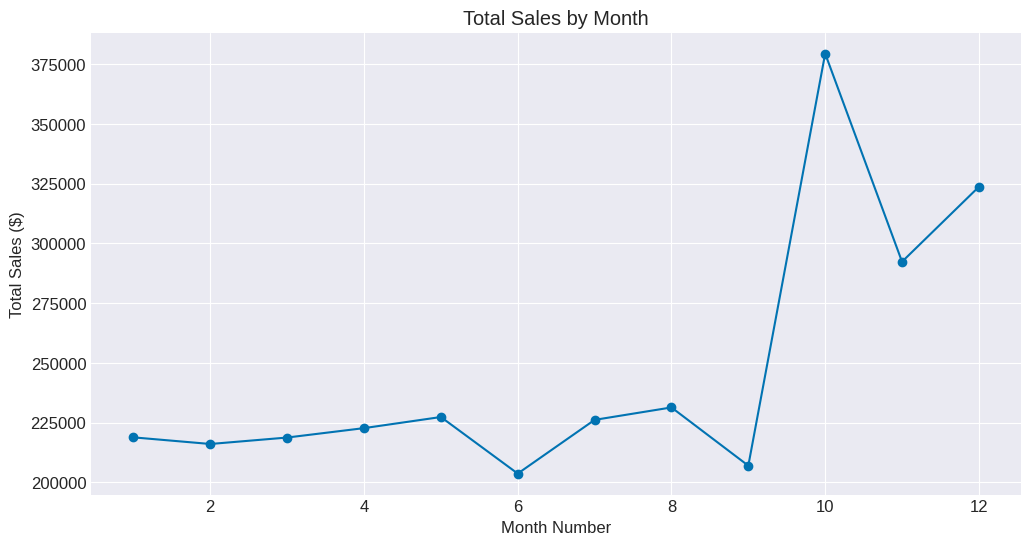

In [19]:
# ============================================================================
# Visualization 1: Monthly Sales Trend
# Write your code below
# ============================================================================

# --- STEP 1: Grouping the data ---
# This line groups all orders by month and adds up the total Sales for each month
monthly_sales = df.groupby('Order_Month')['Sales'].sum()

# --- STEP 2: Creating the plot ---
# We tell pandas to make a line chart ('line') and add little circles ('o') at each data point
monthly_sales.plot(kind='line', marker='o')

# --- STEP 3: Formatting the labels ---
# These lines add the title and the labels for the bottom (x) and side (y) of the chart
plt.title('Total Sales by Month')
plt.xlabel('Month Number')
plt.ylabel('Total Sales ($)')

# --- STEP 4: Display ---
# This command tells Colab to actually draw the chart on the screen
plt.show()

#### ✏️ Visualization 1 — Reflection

Edit this cell to answer the question below:

**Looking at your chart, which month(s) appear to have the highest total sales? Why do you think that might be?**

October through December, with October having the most sales. Megamart must have great end of year deals.

---
### 📊 Visualization 2: Total Sales by Product Category

**Business question:** Which product category brings in the most total sales?

**What to build:** A bar chart showing total `Sales` for each value in the `Category` column.

**Steps to follow:**
1. Group the data by `Category` and sum the `Sales` column
2. Plot the result as a bar chart using `.plot(kind='bar')`
3. Add a title, axis labels, and use `plt.xticks(rotation=0)` to keep the category names horizontal
4. Call `plt.show()`

> 💡 **Hint:** Same pattern as Visualization 1 — just swap `Order_Month` for `Category` and use `kind='bar'`.

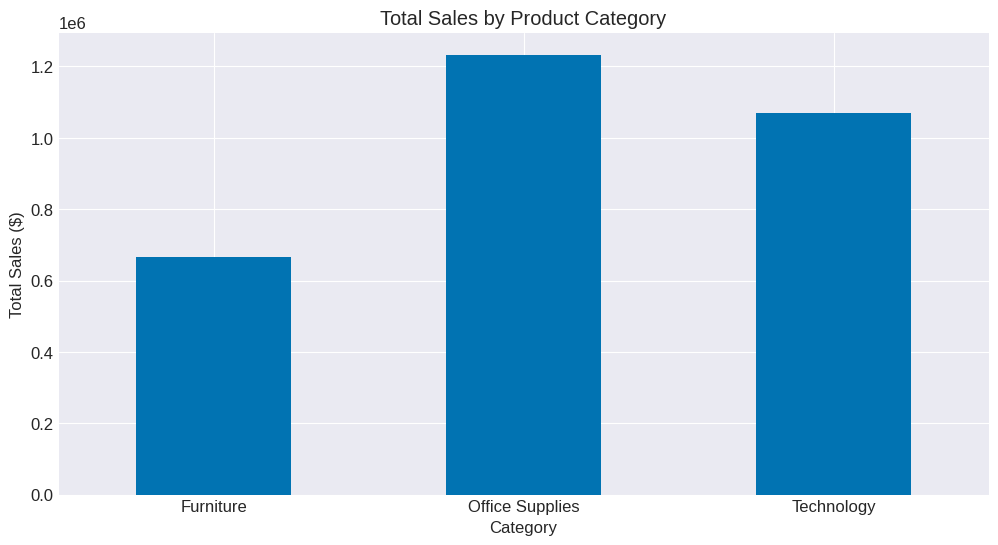

In [20]:
# ============================================================================
# Visualization 2: Total Sales by Product Category
# Write your code below
# ============================================================================

# --- STEP 1: Grouping by Category ---
# This creates a summary showing the total money made for each product category
cat_sales = df.groupby('Category')['Sales'].sum()

# --- STEP 2: Plotting a Bar Chart ---
# We use 'bar' here because we are comparing different groups (Furniture, Tech, etc.)
cat_sales.plot(kind='bar')

# --- STEP 3: Labels and Titles ---
plt.title('Total Sales by Product Category')
plt.ylabel('Total Sales ($)')

# --- STEP 4: Cleaning up the view ---
# This makes the category names sit flat (horizontal) so they are easier to read
plt.xticks(rotation=0)
plt.show()

#### ✏️ Visualization 2 — Reflection

Edit this cell to answer the question below:

**Which category has the highest total sales? Does that surprise you? What might this tell the MegaMart team about where to focus their attention?**

Office supplies has the highest total sales. Businesses seem to be focused on stocking up their office supplies for the next year. Megamart should focus their attention on the specific items in this category that are the best sellers to make sure there is ample inventory. Offer bulk deals to their best customers. It can also help them create an email marketing campaign to those customers to remind them it is time to stock up.

---
### 📊 Visualization 3: Returned vs. Not Returned Orders

**Business question:** How many orders were returned compared to orders that were kept?

**What to build:** A bar chart showing the count of orders for each value in the `Returned` column (`Yes` / `No`).

**Steps to follow:**
1. Use `.value_counts()` on the `Returned` column to count how many orders fall into each group
2. Plot the result as a bar chart
3. Add a title, axis labels, and use `plt.xticks(rotation=0)` to keep the labels horizontal
4. Call `plt.show()`

> 💡 **Hint:**
> ```python
> df['Returned'].value_counts().plot(kind='bar')
> ```

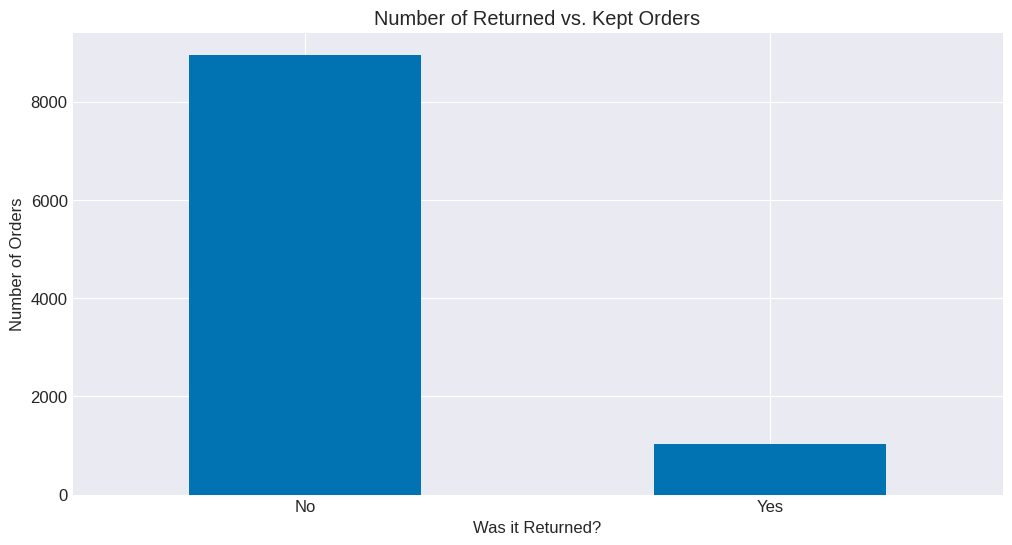

In [21]:
# ============================================================================
# Visualization 3: Returned vs. Not Returned Orders
# Write your code below
# ============================================================================

# --- STEP 1: Counting the values ---
# value_counts() looks at the 'Returned' column and counts how many 'Yes' and 'No' there are
# then we immediately tell it to plot a bar chart
df['Returned'].value_counts().plot(kind='bar')

# --- STEP 2: Formatting ---
plt.title('Number of Returned vs. Kept Orders')
plt.xlabel('Was it Returned?')
plt.ylabel('Number of Orders')

# --- STEP 3: Horizontal Labels ---
# Ensures the 'Yes' and 'No' labels at the bottom aren't tilted sideways
plt.xticks(rotation=0)
plt.show()

#### ✏️ Visualization 3 — Reflection

Edit this cell to answer the question below:

**What percentage of orders were returned (roughly)? Why might this information be useful for a retail business?**

Roughly 11% returned orders. Even though it is not a large percentage (the company's return policy is working) they still need to know why those items are returned and address it.

---
# 💡 Part 3: Business Insights

You have cleaned the data and made three charts. Now it's time to think like an analyst.

In the cells below, write **two business insights** — one or two sentences each — based on what you observed in your charts. An insight goes beyond just describing what a chart shows; it connects the data to a real decision or action the business could take.

---

**Example of a weak insight:**
> "The bar chart shows that Technology has the highest sales."

**Example of a stronger insight:**
> "Technology has the highest total sales of all three categories, which suggests MegaMart may want to ensure strong inventory levels for technology products heading into peak sales months to avoid stockouts."

---

#### ✏️ Your Business Insights

**Insight 1** *(based on any of your three charts)*:

Sales skyrocket in the fourth quarter, peaking in October. This suggests that customers are likely doing significant early holiday shopping or responding to major fall promotional events. MegaMart should ensure maximum staffing and inventory levels starting in September to prepare for this surge.

---

**Insight 2** *(based on any of your three charts)*:

We see significant 'valleys' in June and September, which are the lowest sales periods of the year. To keep revenue steady, MegaMart could launch 'Mid-Summer' or 'Back-to-School' sales campaigns during these months to encourage spending during these typically slow periods.

---
# 📤 Submission Checklist

Before submitting, go through each item below. Replace `[ ]` with `[x]` once it's done:

**Setup**
- [x] My notebook is named `firstInitial_LastName_P1W8.ipynb` (e.g., `A_Smith_P1W8.ipynb`)
- [x] All code cells have been run and show output (no empty output cells)

**Part 1: Data Cleaning**
- [???] Task 1: I answered the three reflection questions about data types (I don't see three reflection questions about data types.)
- [x] Task 2: Both `Order_Date` and `Ship_Date` are converted to `datetime64`
- [x] Task 3: I created `Order_Year`, `Order_Month`, and `Order_Month_Name` columns
- [x] Task 4: The unit test for missing Sales values passes ✅
- [x] Task 5: I checked for and handled duplicate rows
- [x] Task 6: The `Returned` column values are consistently capitalized
- [x] Part 1 Final Check cell runs without errors

**Part 2: Visualizations**
- [x] Visualization 1: Line chart of monthly sales — has a title, labeled axes, and a written reflection
- [x] Visualization 2: Bar chart of sales by category — has a title, labeled axes, and a written reflection
- [x] Visualization 3: Bar chart of returned vs. not returned — has a title, labeled axes, and a written reflection

**Part 3: Insights**
- [x] I wrote two business insights in my own words (not just descriptions of the charts)

**Code Quality**
- [x] My code cells have comments explaining what each section does
